In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_Car_Sales = pd.read_csv('Car_Sales/car_sales_data.csv')

In [3]:
df_Car_Sales.head()

,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [4]:
#Year of manufacture of Latest car in the dataset 

df_Car_Sales['Year of manufacture'].max()

2022

In [5]:
#Year of manufacture of oldest car in the dataset

df_Car_Sales['Year of manufacture'].min()

1984

In [6]:
df_Car_Sales.columns

Index(['Manufacturer', 'Model', 'Engine size', 'Fuel type',
       'Year of manufacture', 'Mileage', 'Price'],
      dtype='object')

In [8]:
#The naming of the columns are not consistent, therefore will change the names of the columns to lower case to make code writing easier and faster.

df_Car_Sales.columns = df_Car_Sales.columns.str.lower()

#Check to see if dataframe columns have been changed to lower cases
df_Car_Sales.head()

,manufacturer,model,engine size,fuel type,year of manufacture,mileage,price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [9]:
# df_Car_Sales_lower

In [10]:
# Retrieve the index of the car with the highest price and assign to a variable
highest_price_car_index = df_Car_Sales['price'].idxmax()

In [12]:
# Use the index of highest priced car to retrieve all relevant details of the car

df_highest_price_car = df_Car_Sales.loc[highest_price_car_index]
df_highest_price_car

manufacturer              BMW
model                      M5
engine size               5.0
fuel type              Petrol
year of manufacture      2022
mileage                  4590
price                  168081
Name: 22786, dtype: object

In [13]:
#Retrieve the index of car with the lowest price and assign it to a variable

lowest_price_car_index = df_Car_Sales['price'].idxmin()

In [14]:
# Use the above index to retrieve full details of car with the lowest sale price
df_lowest_price_car = df_Car_Sales.loc[lowest_price_car_index]
df_lowest_price_car

manufacturer               VW
model                    Polo
engine size               1.0
fuel type              Petrol
year of manufacture      1987
mileage                422895
price                      76
Name: 18063, dtype: object

In [15]:
df_Car_Sales.head()

,manufacturer,model,engine size,fuel type,year of manufacture,mileage,price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


In [16]:
# Get the unique list of car manufacturers on the list

df_Car_Sales['manufacturer'].unique()

array(['Ford', 'Porsche', 'Toyota', 'VW', 'BMW'], dtype=object)

In [17]:
# Group by the above manufacturer category and count the number of sales entries per manufacturer

df_Car_Sales.groupby('manufacturer')['manufacturer'].count().sort_values(ascending=False)

manufacturer
Ford       14959
VW         14913
Toyota     12554
BMW         4965
Porsche     2609
Name: manufacturer, dtype: int64

In [18]:
# Group by the manufacturer category and sum the number of sales entries per manufacturer

df_Car_Sales.groupby('manufacturer').size().reset_index(name='sales count').sort_values(by='manufacturer', ascending=False)

,manufacturer,sales count
4,VW,14913
3,Toyota,12554
2,Porsche,2609
1,Ford,14959
0,BMW,4965


In [19]:
# Sales count by Fuel type

df_SalesCount_ByFuelType = df_Car_Sales.groupby('fuel type').size().reset_index(name='sales count').sort_values(by='sales count', ascending=False)
df_SalesCount_ByFuelType

,fuel type,sales count
2,Petrol,25488
0,Diesel,13268
1,Hybrid,11244


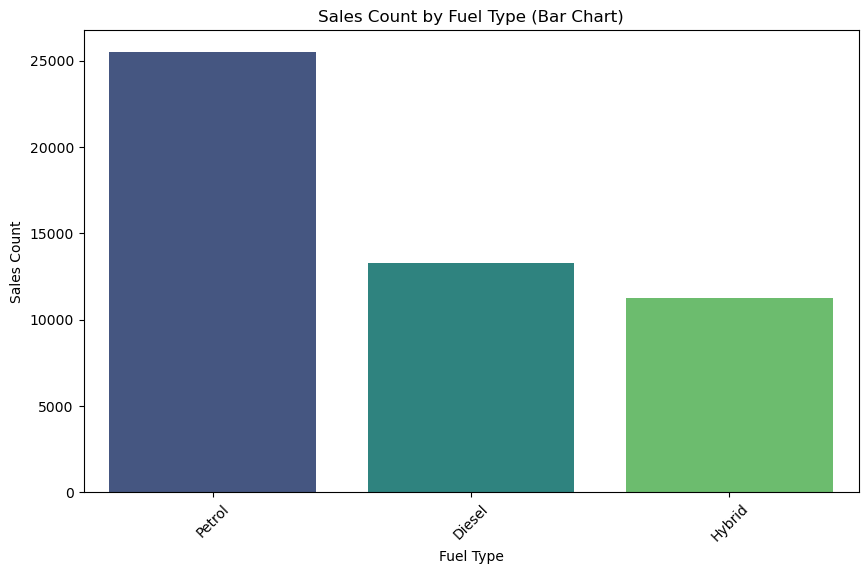

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='fuel type', y='sales count', data=df_SalesCount_ByFuelType, palette='viridis')
plt.title('Sales Count by Fuel Type (Bar Chart)')
plt.xlabel('Fuel Type')
plt.ylabel('Sales Count')
plt.xticks(rotation=45)
plt.show()

In [22]:
# Sales count by Fuel type with percentage

df_SalesCount_ByFuelType_WithPerc = df_Car_Sales.groupby('fuel type').size().reset_index(name='sales count').sort_values(by='sales count', ascending=False)
df_SalesCount_ByFuelType_WithPerc

,fuel type,sales count
2,Petrol,25488
0,Diesel,13268
1,Hybrid,11244


In [23]:
# Sales count by Fuel type with percentage of total

total_sales = df_SalesCount_ByFuelType_WithPerc['sales count'].sum().round(2)
df_SalesCount_ByFuelType_WithPerc['percent_of_total'] = (df_SalesCount_ByFuelType_WithPerc['sales count'] / total_sales).round(4) * 100
df_SalesCount_ByFuelType_WithPerc

,fuel type,sales count,percent_of_total
2,Petrol,25488,50.98
0,Diesel,13268,26.54
1,Hybrid,11244,22.49


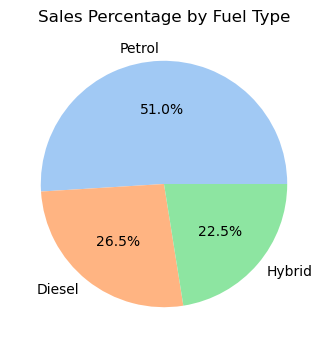

In [24]:
# Assuming df_SalesCount_ByFuelType_WithPerc is already prepared
# and has columns: 'Fuel Type' (or similar) and 'percent_of_total'

# Set Seaborn color palette
colors = sns.color_palette('pastel')[0:len(df_SalesCount_ByFuelType_WithPerc)]

plt.figure(figsize=(4, 4))
plt.pie(
    df_SalesCount_ByFuelType_WithPerc['percent_of_total'],
    labels=df_SalesCount_ByFuelType_WithPerc['fuel type'], # Replace with your actual Fuel Type column name
    autopct='%.1f%%',
    colors=colors
)
plt.title('Sales Percentage by Fuel Type')
plt.show()

In [25]:
df_Car_Sales.groupby(['manufacturer', 'fuel type']).size().reset_index(name='sales count').sort_values(by='manufacturer', ascending=False)

,manufacturer,fuel type,sales count
9,VW,Diesel,5892
10,VW,Hybrid,513
11,VW,Petrol,8508
7,Toyota,Hybrid,9718
8,Toyota,Petrol,2836
5,Porsche,Diesel,276
6,Porsche,Petrol,2333
2,Ford,Diesel,5825
3,Ford,Hybrid,1013
4,Ford,Petrol,8121


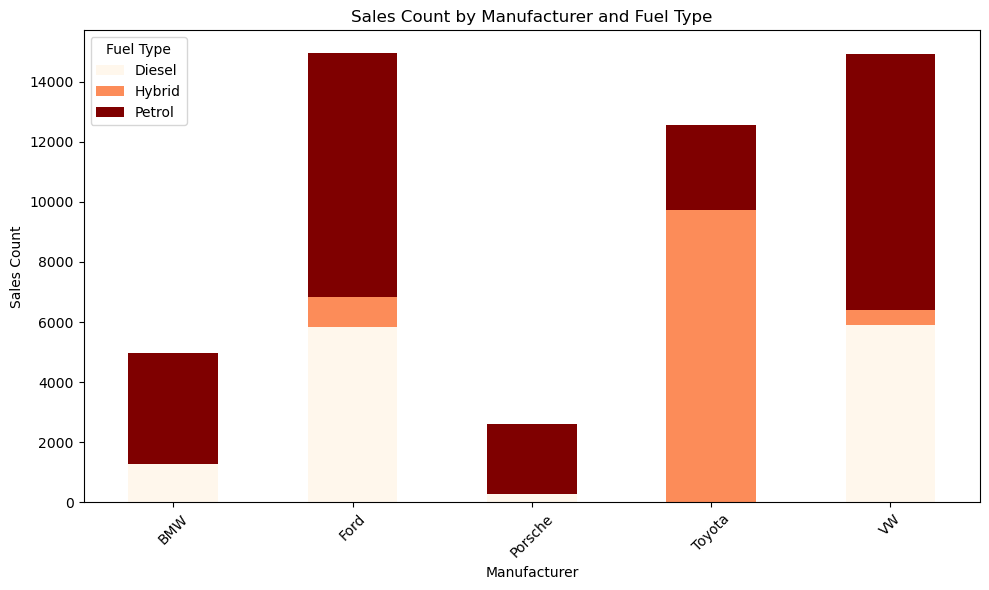

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# ... (Your steps 1 & 2 remain the same)
df_grouped = df_Car_Sales.groupby(['manufacturer', 'fuel type']).size().reset_index(name='sales count').sort_values(by='manufacturer', ascending=False)
df_pivot = df_grouped.pivot(index='manufacturer', columns='fuel type', values='sales count').fillna(0)

# 3. Plot with warm colormap
# Options: 'OrRd', 'YlOrRd', 'inferno', 'hot'
df_pivot.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='OrRd')

plt.title('Sales Count by Manufacturer and Fuel Type')
plt.ylabel('Sales Count')
plt.xlabel('Manufacturer')
plt.legend(title='Fuel Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [27]:
#Engine capacity with the most sales i.e count and value, year make with the most sales i.e count and value

df_SalesCount_ByEngine = df_Car_Sales.groupby('engine size').size().reset_index(name='sales count').sort_values(by='sales count', ascending=False)
df_SalesCount_ByEngine

,engine size,sales count
2,1.4,10060
5,2.0,7631
4,1.8,7032
0,1.0,6343
3,1.6,5509
1,1.2,4984
7,2.4,2364
6,2.2,1678
9,3.0,1368
11,4.0,1092


In [28]:
# Row index of Engine capacity with the most sales

EngineWith_HighestSale_index= df_SalesCount_ByEngine['sales count'].idxmax()

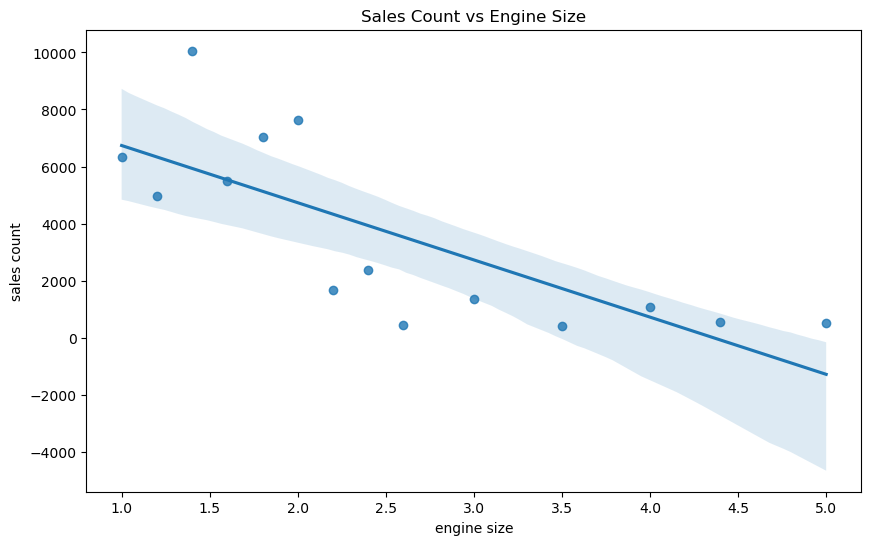

In [38]:
# 1. Your existing code
# Assuming df_Car_Sales is already defined
# df_SalesCount_ByEngine = df_Car_Sales.groupby('engine size').size().reset_index(name='sales count').sort_values(by='sales count', ascending=False)

# 2. Setup the Plot
plt.figure(figsize=(10, 6))

# Approach 1: Using Seaborn (Recommended for better formatting)
sns.regplot(data=df_SalesCount_ByEngine, x='engine size', y='sales count')
plt.title('Sales Count vs Engine Size')
plt.show()

In [30]:
# Engine capacity with the most sale

EngineWith_HighestSale_Details = df_SalesCount_ByEngine.loc[EngineWith_HighestSale_index]
EngineWith_HighestSale_Details

engine size        1.4
sales count    10060.0
Name: 2, dtype: float64

In [31]:
# Sales distribution by year of manufacture across all manufacturers (looks like older models are in more demand)

df_Sales_ByYearofManufacture = df_Car_Sales.groupby('year of manufacture').size().reset_index(name='sales count').sort_values(by='sales count', ascending=False)
df_Sales_ByYearofManufacture

,year of manufacture,sales count
34,2018,1646
11,1995,1616
32,2016,1587
28,2012,1583
20,2004,1578
29,2013,1576
27,2011,1573
22,2006,1566
23,2007,1561
15,1999,1555


In [32]:
# Sales distribution by year of manufacture for every manufacturer ()

df_Sales_YearofManufact_ForEveryManufact = df_Car_Sales.groupby(['manufacturer', 'year of manufacture']).size().reset_index(name='sales count').sort_values(by='sales count', ascending=False)
df_Sales_YearofManufact_ForEveryManufact

,manufacturer,year of manufacture,sales count
190,VW,2018,512
180,VW,2008,508
167,VW,1995,506
176,VW,2004,505
53,Ford,1998,498
...,...,...,...
116,Porsche,2022,24
80,Porsche,1986,22
0,BMW,1984,20
79,Porsche,1985,15


In [33]:
# Sales count by value i.e Total Revenue

df_Sales_ByValue = df_Car_Sales.groupby('manufacturer')['price'].sum().reset_index(name='Revenue').sort_values(by='manufacturer', ascending=False)
df_Sales_ByValue

,manufacturer,Revenue
4,VW,154545496
3,Toyota,180028908
2,Porsche,75931722
1,Ford,159646767
0,BMW,121292265


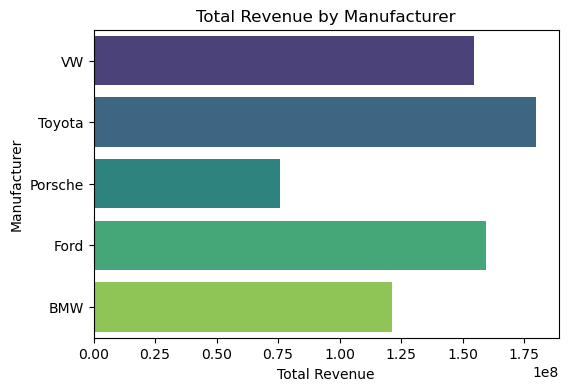

In [34]:
# Your provided data processing
# df_Sales_ByValue = df_Car_Sales.groupby('manufacturer')['price'].sum().reset_index(name='Revenue').sort_values(by='manufacturer', ascending=False)

# Create horizontal bar plot
plt.figure(figsize=(6, 4)) # Set figure size for better readability
sns.barplot(
    data=df_Sales_ByValue,
    x='Revenue',
    y='manufacturer',
    palette='viridis' # Optional: Adds color mapping
)

plt.title('Total Revenue by Manufacturer')
plt.xlabel('Total Revenue')
plt.ylabel('Manufacturer')
plt.show()